In [1]:
import pandas as pd
from sklearn.mixture import GaussianMixture
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import numpy as np
from hmmlearn.hmm import GaussianHMM
import hdbscan
import plotly.graph_objects as go



In [2]:
with open('../../data/nifty_ts2vec_embeddings.pkl', 'rb') as f:
    df = pickle.load(f)

In [3]:
df = df.loc["2020-04-01":]

In [4]:
embeddings = df.drop("Close", axis=1)
embeddings

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Date,,,,,,,,,,,,,,,,,,,,,
2020-04-01 00:00:00+05:30,0.000000,0.094752,0.000000,0.090752,0.000000,0.018957,0.087032,0.035068,0.001766,0.006801,...,0.040424,0.090216,0.001129,0.006993,0.170005,0.072506,0.0,0.037220,0.012506,0.009122
2020-04-03 00:00:00+05:30,0.000000,0.094533,0.000000,0.086520,0.000000,0.022193,0.079634,0.034724,0.003363,0.008332,...,0.047089,0.087457,0.002840,0.003782,0.178860,0.059813,0.0,0.036648,0.011250,0.004269
2020-04-07 00:00:00+05:30,0.000000,0.093165,0.000000,0.083509,0.000000,0.023746,0.073619,0.032738,0.006700,0.010302,...,0.053322,0.083218,0.004673,0.001949,0.186899,0.045395,0.0,0.036115,0.009638,0.002161
2020-04-08 00:00:00+05:30,0.000000,0.092824,0.000000,0.081186,0.000000,0.026054,0.066119,0.031213,0.009549,0.012566,...,0.059550,0.077441,0.005136,0.000000,0.194680,0.033584,0.0,0.034344,0.010105,0.000442
2020-04-09 00:00:00+05:30,0.000000,0.094438,0.000000,0.076924,0.000000,0.027639,0.060387,0.030907,0.012264,0.014997,...,0.064920,0.069459,0.003053,0.000000,0.203905,0.022452,0.0,0.031763,0.011765,0.000569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12 00:00:00+05:30,0.150253,0.171876,0.110617,0.016477,0.000274,0.000000,0.104171,0.077467,0.020435,0.000000,...,0.041521,0.073654,0.000000,0.000000,0.025725,0.050502,0.0,0.019644,0.066028,0.036041
2025-09-15 00:00:00+05:30,0.140572,0.171512,0.102708,0.012511,0.000518,0.000000,0.113352,0.073049,0.019066,0.000000,...,0.039853,0.072866,0.000000,0.000000,0.025318,0.053611,0.0,0.021749,0.061992,0.034028
2025-09-16 00:00:00+05:30,0.128521,0.175892,0.093519,0.008835,0.000000,0.000000,0.121123,0.067323,0.016315,0.000000,...,0.037340,0.075898,0.000000,0.000000,0.024032,0.058974,0.0,0.025540,0.057928,0.034247


In [5]:
30*0.6

18.0

In [6]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=6,
    metric="euclidean",
    cluster_selection_method="leaf",
    cluster_selection_epsilon = 0.1,   
    allow_single_cluster=False,
    prediction_data=True
)
labels = clusterer.fit_predict(embeddings)

In [7]:
df["HDBSCAN_Labels"] = labels

In [8]:
df["HDBSCAN_Labels"].value_counts(normalize=True).head()

HDBSCAN_Labels
-1     0.120473
 15    0.099039
 3     0.097561
 10    0.079823
 8     0.070214
Name: proportion, dtype: float64

In [9]:
df["HDBSCAN_Labels"].value_counts(normalize=True).head().to_clipboard()

In [10]:
df["HDBSCAN_Labels"].nunique() #51

18

In [11]:
fig = go.Figure()

# Scatter per regime/cluster
for c in sorted(df["HDBSCAN_Labels"].dropna().unique()):
    mask = df["HDBSCAN_Labels"] == c
    fig.add_trace(
        go.Scatter(
            x=df.index[mask],
            y=df.loc[mask, "Close"],
            mode="markers",
            name=f"Regime {c}",
            marker=dict(size=6),
        )
    )

# Underlay full close series
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
    )
)

fig.update_layout(
    title="Nifty 50 Regimes (Clustering)",
    # width=1400,
    height=820,
    legend_title_text="Regime",
    xaxis_title="Date",
    yaxis_title="Close",
    template="plotly_white",
)

fig.show()

In [12]:
# plt.figure(figsize=(25,6))

# for c in df['HDBSCAN_Labels'].dropna().unique():
#     mask = df['HDBSCAN_Labels'] == c
#     plt.scatter(df.index[mask], df['Close'][mask], label=f"Regime {c}", s=10)
# plt.plot(df.index, df['Close'], color='black', linewidth=0.5, alpha=0.6)
# plt.title("Nifty 50 Regimes (Clustering)")
# plt.legend()
# plt.show()

In [13]:
hdb_labels = df["HDBSCAN_Labels"].values

In [14]:
from sklearn.metrics import pairwise_distances_argmin

# Ensure we operate on numpy arrays (pairwise_distances_argmin expects array-like)
X = embeddings.to_numpy() if hasattr(embeddings, "to_numpy") else np.asarray(embeddings)
labels = np.asarray(hdb_labels).copy()

# centroids from non-noise clusters
clusters = np.unique(labels[labels >= 0])

# If everything is noise (or there are no points), we can't reassign
if clusters.size == 0:
    print("No non-noise clusters found; leaving labels unchanged.")
else:
    centroids = np.vstack([X[labels == k].mean(axis=0) for k in clusters])

    # reassign noise (if any) to nearest centroid
    noise_idx = np.where(labels == -1)[0]
    if noise_idx.size == 0:
        print("No noise points to reassign.")
    else:
        nearest = pairwise_distances_argmin(X[noise_idx], centroids)
        labels[noise_idx] = clusters[nearest]

In [15]:
np.mean(labels == -1)

0.0

In [16]:
len(centroids)

17

In [17]:
from sklearn.cluster import AgglomerativeClustering

K0 = 15  # start here

agg = AgglomerativeClustering(
    n_clusters=K0,
    linkage="ward"
)

proto_labels = agg.fit_predict(centroids)

In [18]:
proto_labels

array([12,  9,  7, 14,  0,  0, 11, 13,  5, 10,  8,  0,  6,  4,  2,  3,  1])

In [19]:
proto_state = np.zeros_like(labels)
cluster_ids = np.unique(labels)

for cid, p in zip(cluster_ids, proto_labels):
    proto_state[labels == cid] = p

In [20]:
np.unique(proto_state)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [21]:
def init_from_micro_regimes(X, labels, min_points=20):
    states = np.unique(labels)
    means, covs = [], []

    for k in states:
        pts = X[labels == k]
        if len(pts) < min_points:
            continue
        means.append(pts.mean(axis=0))
        covs.append(
            np.cov(pts.T) + 1e-6 * np.eye(X.shape[1])
        )

    return np.array(means), np.array(covs)


def full_to_diag_cov(covs):
    """
    covs: (K, D, D)
    returns: (K, D)
    """
    return np.array([
        np.diag(cov) for cov in covs
    ])


def init_from_proto_states_diag(X, proto_state, min_points=50):
    states = np.unique(proto_state)
    means, diag_covs = [], []

    for k in states:
        pts = X[proto_state == k]
        if len(pts) < min_points:
            continue

        mu = pts.mean(axis=0)
        cov = np.cov(pts.T)

        # strong regularization for stability
        cov += 1e-3 * np.eye(X.shape[1])

        means.append(mu)
        diag_covs.append(np.diag(cov))

    return np.array(means), np.array(diag_covs)

In [22]:
init_means, init_covs = init_from_proto_states_diag(
    embeddings, proto_state
)

K = len(init_means)
print("HMM init states:", K)

HMM init states: 10


In [23]:
from hmmlearn.hmm import GaussianHMM

def sticky_transition(K, kappa=70, base=1.0):
    A = np.full((K, K), base)
    np.fill_diagonal(A, base + kappa)
    return A / A.sum(axis=1, keepdims=True)


model = GaussianHMM(
    n_components=K,
    covariance_type="diag",   
    n_iter=1500,
    tol=1e-3,
    init_params=""
)

model.startprob_ = np.ones(K) / K
model.transmat_ = sticky_transition(K)
model.means_ = init_means
model.covars_ = init_covs

model.fit(embeddings)

,n_components,10
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,None


In [24]:
# save the model
with open('../../models/nifty_hmm_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [25]:
post = model.predict_proba(embeddings)
state_mass = post.mean(axis=0)

print("Effective states:",
      np.sum(state_mass > 0.01))

Effective states: 10


In [26]:
len(state_mass)

10

In [27]:
state_mass

array([0.16006809, 0.07762395, 0.12250354, 0.08498957, 0.16425494,
       0.05026337, 0.07175021, 0.04877434, 0.08804173, 0.13173026])

In [27]:
keep = state_mass > 0.03
posteriors = post[:, keep]

In [28]:
posteriors.shape

(1353, 10)

In [29]:
viterbi = model.predict(embeddings)
np.mean(viterbi[1:] == viterbi[:-1])

0.985207100591716

In [30]:
len(viterbi)

1353

In [31]:
df["HMM_Labels"] = viterbi

In [32]:
df["HMM_Labels"].value_counts()

HMM_Labels
4    222
0    217
9    178
2    166
8    119
3    115
1    105
6     97
5     68
7     66
Name: count, dtype: int64

In [33]:
fig = go.Figure()

# Scatter per regime/cluster
for c in sorted(df["HMM_Labels"].dropna().unique()):
    mask = df["HMM_Labels"] == c
    fig.add_trace(
        go.Scatter(
            x=df.index[mask],
            y=df.loc[mask, "Close"],
            mode="markers",
            name=f"Regime {c}",
            marker=dict(size=6),
        )
    )

# Underlay full close series
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
    )
)

fig.update_layout(
    title="Nifty 50 Regimes (Clustering)",
    # width=1400,
    height=820,
    legend_title_text="Regime",
    xaxis_title="Date",
    yaxis_title="Close",
    template="plotly_white",
)

fig.show()

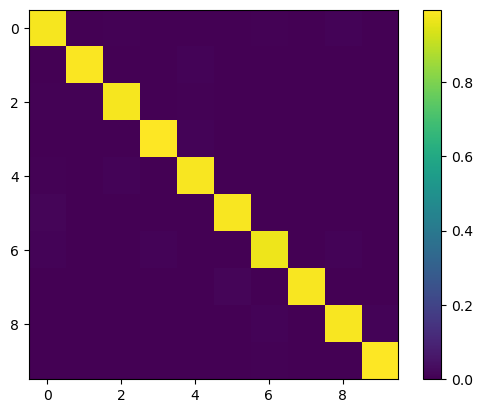

In [34]:
plt.imshow(model.transmat_, cmap="viridis")
plt.colorbar()

In [ ]:
def compute_state_signatures(
    states,
    returns,
    volatility,
    price,
    lookback_weight=None
):
    """
    returns DataFrame of shape (K, features)
    """

    K = int(states.max()) + 1
    sig = []
    print("Computing signatures for", K, "states")

    T = len(states)
    weights = (
        np.exp(-np.arange(T)[::-1] / lookback_weight)
        if lookback_weight is not None
        else np.ones(T)
    )

    for k in range(K):
        print(f"State {k}: ", end="")
        idx = states == k
        if idx.sum() < 30:
            print("Ignoring ", idx)
            continue

        w = weights[idx]

        sig.append({
            "state": k,
            "freq": idx.mean(),
            "mean_return": np.average(returns[idx], weights=w),
            "volatility": np.average(volatility[idx], weights=w),
            "trend": np.polyfit(
                np.arange(idx.sum()),
                price[idx],
                1
            )[0],
            "drawdown": np.min(
                price[idx] / np.maximum.accumulate(price[idx]) - 1
            ),
        })

    return pd.DataFrame(sig).set_index("state")

In [36]:
# X_emb        # ts2vec embeddings (T, D)
# returns      # daily log returns (T,)
# volatility   # rolling vol (T,)
# price        # index price (T,)
# states       # HMM state sequence (T,)
# posteriors   # HMM posteriors (T, K)

returns = np.log(df["Close"] / df["Close"].shift(1)).fillna(0).values
volatility = df["Close"].rolling(20).std().bfill().values
price = df["Close"].values
states = viterbi
state_df = compute_state_signatures(
    states, returns, volatility, price, lookback_weight=100
)


Computing signatures for 10 states
State 0: State 1: State 2: State 3: State 4: State 5: State 6: State 7: State 8: State 9: 

In [37]:

state_df.sort_values("freq", ascending=False)

,freq,mean_return,volatility,trend,drawdown
state,,,,,
4,0.164080,0.001186,336.370838,26.049731,-0.164659
0,0.160384,-0.000144,256.242076,63.344653,-0.077634
9,0.131559,0.001422,282.807574,15.976430,-0.066119
2,0.122690,-0.000430,249.279962,26.146615,-0.069283
8,0.087953,0.000966,211.877102,77.183934,-0.067177
3,0.084996,0.000565,414.592213,-7.200630,-0.108431
1,0.077605,0.000402,264.561235,10.048403,-0.100820
6,0.071693,-0.000121,311.378996,29.653791,-0.037780
5,0.050259,0.001590,183.672307,10.639703,-0.072294


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

features = [
    "mean_return",
    "volatility",
    "trend",
    "drawdown",
]

X_state = StandardScaler().fit_transform(state_df[features])

clusterer = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

state_df["macro_regime"] = clusterer.fit_predict(X_state)

In [39]:
state_to_macro = state_df["macro_regime"].to_dict()
macro_states = np.array([state_to_macro[s] for s in states])

In [40]:
macro_summary = (
    state_df
    .groupby("macro_regime")
    .agg({
        "mean_return": "mean",
        "volatility": "mean",
        "trend": "mean",
        "drawdown": "mean",
    })
)

In [41]:
labels = {}

ret_rank = macro_summary["mean_return"].rank()
vol_rank = macro_summary["volatility"].rank()
dd_rank  = macro_summary["drawdown"].rank()

for k in macro_summary.index:
    if ret_rank[k] == ret_rank.max() and vol_rank[k] <= 3:
        labels[k] = "Strong Bull"

    elif ret_rank[k] >= 4:
        labels[k] = "Bull"

    elif ret_rank[k] <= 2 and dd_rank[k] <= 2:
        labels[k] = "Bear"

    elif vol_rank[k] == vol_rank.max():
        labels[k] = "High Volatility"

    else:
        labels[k] = "Sideways / Transition"

In [42]:
macro_summary["label"] = macro_summary.index.map(labels)

In [43]:
macro_summary

,mean_return,volatility,trend,drawdown,label
macro_regime,,,,,
0,0.000572,258.340015,18.492988,-0.069259,Sideways / Transition
1,0.003986,317.500113,30.004206,-0.105138,Strong Bull
2,0.000411,234.059589,70.264293,-0.072406,Sideways / Transition
3,0.001186,336.370838,26.049731,-0.164659,Bull
4,0.000565,414.592213,-7.200630,-0.108431,Bear


In [65]:
bull_strength = {}

for k, row in macro_summary.iterrows():
    if row["label"] == "Strong Bull":
        bull_strength[k] = 1.0
    elif row["label"] == "Bull":
        bull_strength[k] = 0.75
    elif row["label"] == "Sideways / Transition":
        bull_strength[k] = 0.55
    elif row["label"] == "High Volatility":
        bull_strength[k] = 0.2
    else:  # Bear
        bull_strength[k] = 0.0

In [72]:
def rolling_percentile(x, window=252):
    out = np.full_like(x, np.nan)
    for i in range(window, len(x)):
        out[i] = (
            np.sum(x[i-window:i] <= x[i]) / window
        )
    return out

In [66]:
state_to_macro

{0: 2, 1: 0, 2: 0, 3: 4, 4: 3, 5: 0, 6: 0, 7: 1, 8: 2, 9: 0}

In [67]:
state_bull_strength = {
    s: bull_strength[state_to_macro[s]]
    for s in state_to_macro
}
state_bull_strength

{0: 0.55,
 1: 0.55,
 2: 0.55,
 3: 0.0,
 4: 0.75,
 5: 0.55,
 6: 0.55,
 7: 1.0,
 8: 0.55,
 9: 0.55}

In [68]:
def bull_confidence_from_posteriors(posteriors, state_bull_strength):
    """
    posteriors: (T, K)
    returns: (T,) bull confidence in [0, 1]
    """
    weights = np.array([
        state_bull_strength[k] for k in range(posteriors.shape[1])
    ])
    return posteriors @ weights

In [69]:
posteriors

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        1.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        1.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        1.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       ...,
       [5.02166864e-044, 0.00000000e+000, 1.08958772e-289, ...,
        0.00000000e+000, 1.00000000e+000, 1.92238968e-047],
       [2.97646537e-044, 0.00000000e+000, 2.26265018e-298, ...,
        0.00000000e+000, 1.00000000e+000, 2.29154032e-046],
       [2.27884821e-042, 6.95794625e-318, 2.89695851e-285, ...,
        0.00000000e+000, 1.00000000e+000, 2.77447623e-032]])

In [70]:
bull_conf = bull_confidence_from_posteriors(
    posteriors,
    state_bull_strength
)
bull_conf

array([1.  , 1.  , 1.  , ..., 0.55, 0.55, 0.55])

In [71]:
# plot bull confidence over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf,
        mode="lines",
        name="Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Confidence Over Time",
    xaxis_title="Date",
    yaxis_title="Bull Confidence",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [74]:
def smooth_series(x, half_life=20):
    alpha = 1 - np.exp(np.log(0.5) / half_life)
    y = np.zeros_like(x)
    y[0] = x[0]
    for t in range(1, len(x)):
        y[t] = alpha * x[t] + (1 - alpha) * y[t-1]
    return y

bull_conf_smooth = smooth_series(bull_conf, half_life=20)
bull_conf_rel = rolling_percentile(bull_conf_smooth, 252)

In [76]:
# plot bull_conf_smooth over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf_smooth,
        mode="lines",
        name="Smoothed Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf_rel,
        mode="lines",
        name="Relative Bull Confidence",
        line=dict(color="green", width=2, dash="dash"),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Smoothed Bull Confidence Over Time",
    xaxis_title="Date",
    yaxis_title="Smoothed Bull Confidence",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [53]:
bull_momentum = bull_conf_smooth - smooth_series(
    bull_conf_smooth, half_life=60
)

In [54]:
# plot bull momentum over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_momentum,
        mode="lines",
        name="Bull Momentum",
        line=dict(color="red", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Momentum Over Time",
    xaxis_title="Date",
    yaxis_title="Bull Momentum",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [61]:
from scipy.stats import multivariate_normal

def hmm_filter_step(x_t, prev_gamma, model):
    K = model.n_components

    # emission likelihoods
    lik = np.zeros(K)
    for k in range(K):
        lik[k] = multivariate_normal.pdf(
            x_t,
            mean=model.means_[k],
            cov=model.covars_[k]
        )

    # predict
    pred = prev_gamma @ model.transmat_

    # update
    gamma = pred * lik
    gamma /= gamma.sum()

    return gamma

In [ ]:
gamma_t = posteriors[-1]

bull_conf_live = []

for x_t in new_embeddings:   # streaming TS2Vec embeddings
    gamma_t = hmm_filter_step(x_t, gamma_t, model)

    bc = sum(
        gamma_t[k] * state_bull_strength[k]
        for k in range(len(gamma_t))
    )
    bull_conf_live.append(bc)

In [ ]:
bull_conf_live_smooth = smooth_series(
    np.array(bull_conf_live),
    half_life=20
)

In [60]:
# bull_momentum, bull_conf_smooth, df["Close"]

cdf=pd.DataFrame({
    "bull_momentum": bull_momentum,
    "bull_confidence": bull_conf_smooth,
    "close": df["Close"]
})

In [61]:
cdf

,bull_momentum,bull_confidence,close
Date,,,
2020-04-01 00:00:00+05:30,0.000000,1.000000,8253.799805
2020-04-03 00:00:00+05:30,0.000000,1.000000,8083.799805
2020-04-07 00:00:00+05:30,0.000000,1.000000,8792.200195
2020-04-08 00:00:00+05:30,0.000000,1.000000,8748.750000
2020-04-09 00:00:00+05:30,0.000000,1.000000,9111.900391
...,...,...,...
2025-09-12 00:00:00+05:30,0.101317,0.401985,25114.000000
2025-09-15 00:00:00+05:30,0.100086,0.401917,25069.199219
2025-09-16 00:00:00+05:30,0.098872,0.401852,25239.099609


In [64]:
cdf.reset_index().describe().to_clipboard()